In [ ]:
#LOAD DATASET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
#UNDERSTAND DATASET
df.shape

(50000, 2)

In [4]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
#IMPORT NLP LIBRARIES
import nltk
import re
import string

In [8]:
#DOWNLOAD NLP DATA
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\janak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [9]:
#IMPORT STOPWORDS
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [11]:
#CREATE CLEANING FUNCTION
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # remove extra spaces
    text = text.strip()

    # remove stopwords
    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [13]:
#APPLY CLEANING
df["clean_review"] = df["review"].apply(clean_text)

In [14]:
#CHECK RESULTS
df[
    ["review", "clean_review"]
].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


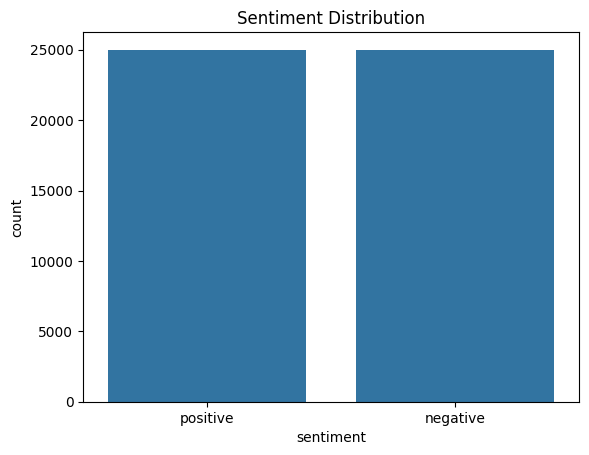

In [15]:
#CHECK SENTIMENT BALANCE
sns.countplot(
    x="sentiment",
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

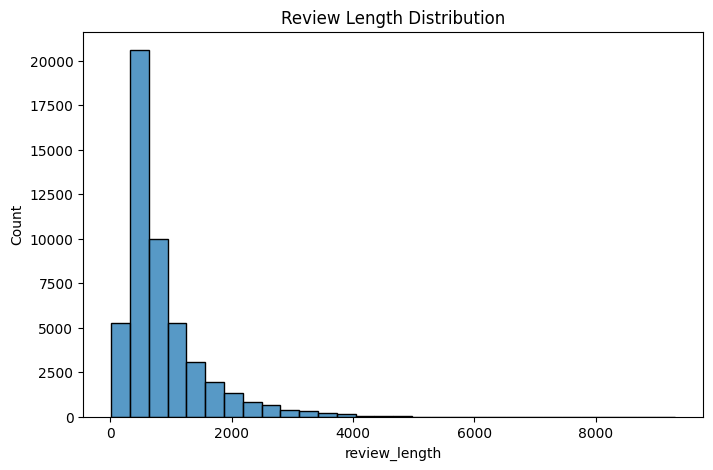

In [17]:
#CHECK REVIEW LENGTH
df["review_length"] = df[
    "clean_review"
].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    df["review_length"],
    bins=30
)

plt.title("Review Length Distribution")

plt.show()

In [19]:
#CONVERT SENTIMENT LABELS
df["sentiment"] = df[
    "sentiment"
].map({
    "positive": 1,
    "negative": 0
})

In [20]:
#IMPORT TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#CREATE TF-IDF VECTORIZER     keep the top 5000 important words.
tfidf = TfidfVectorizer(
    max_features=5000
)

In [25]:
#TRANSFORM TEXT
X = tfidf.fit_transform(
    df["clean_review"]
)

y = df["sentiment"]

In [ ]:
#CHECK SHAPE     50,000 reviews 5000 word features
X.shape

(50000, 5000)

In [28]:
#TRAIN / TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
#CHECK DATA SHAPES
print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [31]:
#IMPORT MODEL
from sklearn.linear_model import LogisticRegression

In [32]:
#CREATE MODEL
model = LogisticRegression()


In [33]:
#TRAIN MODEL
model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
#MAKE PREDICTIONS
y_pred = model.predict(X_test)

In [35]:
#CHECK ACCURACY
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8864


In [36]:
#CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
#TEST CUSTOM REVIEW
#1=positive
review = [
    "This movie was absolutely amazing"
]

review_vector = tfidf.transform(review)

prediction = model.predict(
    review_vector
)

print(prediction)

[1]


In [39]:
#0=negative
review = [
    "Worst movie I have ever seen"
]

review_vector = tfidf.transform(review)

prediction = model.predict(
    review_vector
)

print(prediction)

[0]


In [40]:
#IMPORT NEW MODELS
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [41]:
#CREATE MODELS
lr = LogisticRegression()

nb = MultinomialNB()

svm = LinearSVC()

In [42]:
#TRAIN ALL MODELS
lr.fit(X_train, y_train)

nb.fit(X_train, y_train)

svm.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [43]:
#MAKE PREDICTIONS
lr_pred = lr.predict(X_test)

nb_pred = nb.predict(X_test)

svm_pred = svm.predict(X_test)

In [44]:
#COMPARE ACCURACY
from sklearn.metrics import accuracy_score

print(
    "Logistic Regression:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Naive Bayes:",
    accuracy_score(y_test, nb_pred)
)

print(
    "SVM:",
    accuracy_score(y_test, svm_pred)
)

Logistic Regression: 0.8864
Naive Bayes: 0.8495
SVM: 0.88


In [45]:
#FIND BEST MODEL
results = {
    "Logistic Regression":
        accuracy_score(
            y_test,
            lr_pred
        ),

    "Naive Bayes":
        accuracy_score(
            y_test,
            nb_pred
        ),

    "SVM":
        accuracy_score(
            y_test,
            svm_pred
        )
}

best_model = max(
    results,
    key=results.get
)

print(
    "Best Model:",
    best_model
)

Best Model: Logistic Regression


In [46]:
#SAVE BEST MODEL
import joblib

joblib.dump(
    svm,
    "../models/final_sentiment_model.pkl"
)

['../models/final_sentiment_model.pkl']

In [47]:
#TEST CUSTOM REVIEWS
sample_review = [
    "I absolutely loved this movie"
]

sample_vector = tfidf.transform(
    sample_review
)

prediction = svm.predict(
    sample_vector
)

print(prediction)

[1]


In [48]:
sample_review = [
    "This was terrible and boring"
]

sample_vector = tfidf.transform(
    sample_review
)

prediction = svm.predict(
    sample_vector
)

print(prediction)

[0]


In [49]:
#IMPORT WORDCLOUD
from wordcloud import WordCloud

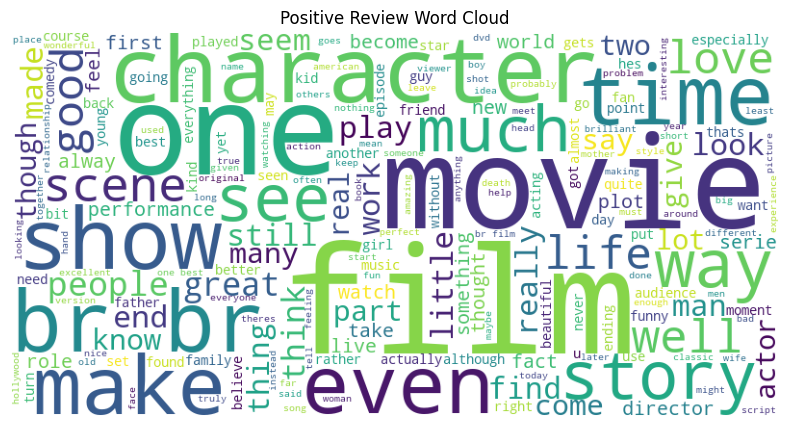

In [50]:
#POSITIVE WORD CLOUD
positive_reviews = " ".join(
    df[
        df["sentiment"] == 1
    ]["clean_review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(
    positive_reviews
)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Positive Review Word Cloud"
)

plt.show()

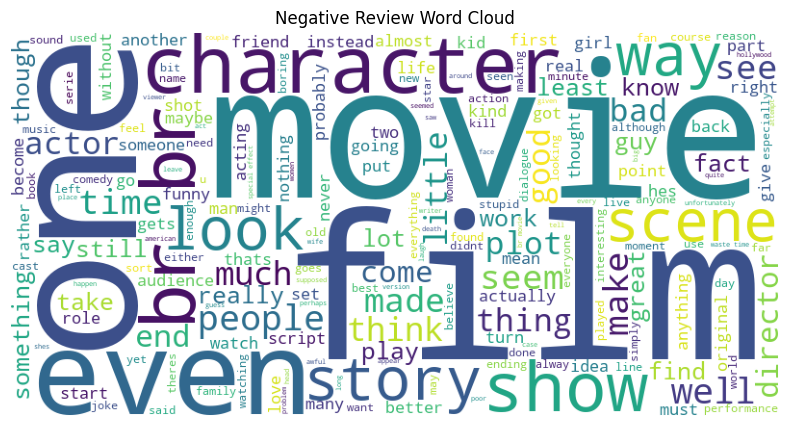

In [51]:
#NEGATIVE WORD CLOUD
negative_reviews = " ".join(
    df[
        df["sentiment"] == 0
    ]["clean_review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(
    negative_reviews
)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Negative Review Word Cloud"
)

plt.show()

In [53]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    svm_pred
)

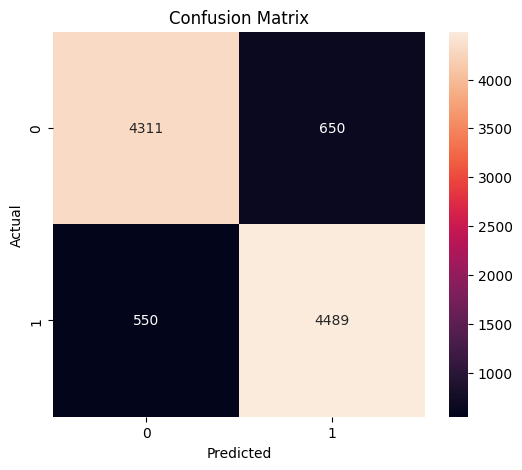

In [54]:
#VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()